<a href="https://colab.research.google.com/github/mani12-svg/Visual-QA-Multimodal/blob/main/Multimodal_visual_Q_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the necessary libraries for Visual Question Answering
!pip install "transformers<5.0.0" torch Pillow matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import pipeline

print("Downloading the Visual Investigator AI... (This might take a minute)")

# 1. Create the Visual Question Answering tool
# We tell the pipeline the task is "visual-question-answering"
vqa_agent = pipeline("visual-question-answering", model="dandelin/vilt-b32-finetuned-vqa")

print("Download complete! The AI is ready for your questions.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/470M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


Download complete! The AI is ready for your questions.


--- AI Visual Investigator is Live! ---
Click 'Choose Files' to upload a photograph (.jpg or .png)


Saving Orlando Summer Brand Minis are still available! If you’re looking to update your website, socials, or overall brand presence online these minis are the perfect way to capture some updated pics!! These aren’t just “h.jpg to Orlando Summer Brand Minis are still available! If you’re looking to update your website, socials, or overall brand presence online these minis are the perfect way to capture some updated pics!! These aren’t just “h (1).jpg

Processing 'Orlando Summer Brand Minis are still available! If you’re looking to update your website, socials, or overall brand presence online these minis are the perfect way to capture some updated pics!! These aren’t just “h (1).jpg'... 🔍

--- The Evidence ---


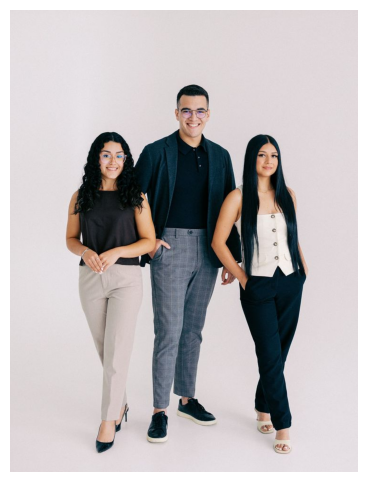


--- Interrogation Started. (Type 'quit' to stop) ---

What is your question about this image? how many humans?
Scanning visual data... 🧠
🤖 Answer: 2 (Confidence: 64.7%)

What is your question about this image? how many females?
Scanning visual data... 🧠
🤖 Answer: 2 (Confidence: 66.3%)

What is your question about this image? how many males?
Scanning visual data... 🧠
🤖 Answer: 1 (Confidence: 66.7%)

What is your question about this image? stop
Visual Investigator: Interrogation complete. Case closed!


In [ ]:
from google.colab import files
from PIL import Image
import io
import matplotlib.pyplot as plt

print("--- AI Visual Investigator is Live! ---")
print("Click 'Choose Files' to upload a photograph (.jpg or .png)")

# 1. Open a file picker to upload an image
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nProcessing '{filename}'... 🔍")

    # Open the image file
    image = Image.open(io.BytesIO(uploaded[filename]))

    # Display the image so you can see what you are analyzing
    print("\n--- The Evidence ---")
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    print("\n--- Interrogation Started. (Type 'quit' to stop) ---")

    # 2. Start the interactive Question & Answer loop
    while True:
        # Get the question from the user
        question = input("\nWhat is your question about this image? ")

        # Check if the user wants to stop
        if question.lower() in ["quit", "exit", "stop"]:
            print("Visual Investigator: Interrogation complete. Case closed!")
            break

        if len(question.strip()) < 3:
            print("System: Please ask a slightly longer question.")
            continue

        try:
            # 3. Hand the image and the question to the AI
            print("Scanning visual data... 🧠")
            results = vqa_agent(image=image, question=question)

            # 4. Extract the top answer and its confidence score
            top_answer = results[0]['answer']
            confidence = round(results[0]['score'] * 100, 1)

            # 5. Print the final result!
            print(f"🤖 Answer: {top_answer.capitalize()} (Confidence: {confidence}%)")

        except Exception as e:
            print(f"An error occurred: {e}")